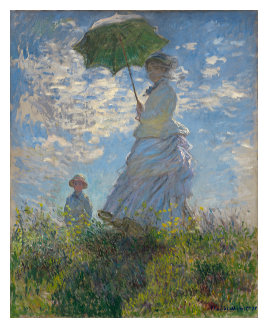

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("monet.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert colors to rgb
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")
plt.show()

This painting is called Woman with a Parasol and was made by Monet in 1875. In the painting we see Monet's wife Mrs. Monet and their son Jean Monet. It is from the Impressionist era which originated from Paris and was big in 1870s and 80s. This painting is currently at the National Art Gallery in Washington D.C. so you can go and check it out in person!

From visually inspecting the painting, the colors seem soft, with lots of soft blue, white, and green/yellow.

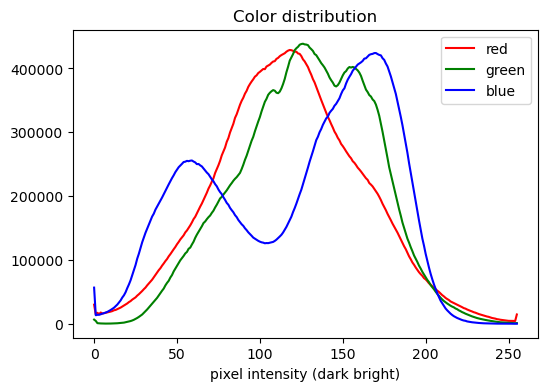

In [9]:
colors = ("red", "green", "blue")
plt.figure(figsize=(6,4))
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color=col, label=col)
plt.title("Color distribution")
plt.xlabel("pixel intensity (dark bright)")
plt.legend()
plt.show()

It is interesting to see blue has two peaks, one bright and the other darker. Darker blue can be seen around the upper portion of the sky. Unsurprisingly, green appears a lot, but surprisingly red also appears. There is virtually no red in the painting, so we can deduce that the reds are being combined with green that produce the plenty of yellow we see on the painting.

Below are alternative ways to show the RGB color distributions. Not required, but feel free to use them if you find them interesting.

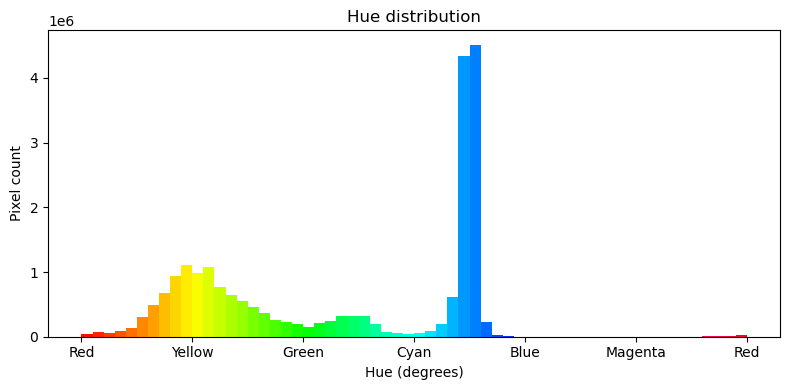

In [10]:
# RGB -> HSV
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H = hsv[:, :, 0].astype(np.float32)   # 0..179
S = hsv[:, :, 1].astype(np.float32)
V = hsv[:, :, 2].astype(np.float32)

# keep only pixels where hue is meaningful
mask = (S > 60) & (V > 40)

# convert hue to degrees 0..360
hue_deg = H[mask] * 2

# histogram
bins = 60
counts, edges = np.histogram(hue_deg, bins=bins, range=(0, 360))
centers = (edges[:-1] + edges[1:]) / 2

# color bars by hue itself
colors = plt.cm.hsv(centers / 360)

plt.figure(figsize=(8, 4))
plt.bar(centers, counts, width=360/bins, color=colors, edgecolor="none")

plt.xlabel("Hue (degrees)")
plt.ylabel("Pixel count")
plt.title("Hue distribution")

plt.xticks(
    [0, 60, 120, 180, 240, 300, 360],
    ["Red", "Yellow", "Green", "Cyan", "Blue", "Magenta", "Red"]
)

plt.tight_layout()
plt.show()


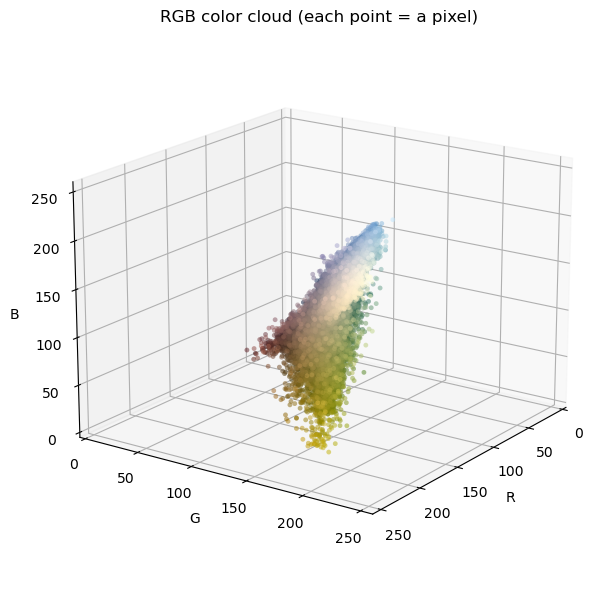

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- flatten pixels ---
pix = img.reshape(-1, 3).astype(np.float32)          # (N, 3) in 0..255
colors = (pix / 255.0)                               # for plotting colors

# --- optional: drop very dark pixels so the cloud isn't dominated by shadows ---
keep = pix.sum(axis=1) > 30   # tune threshold (0..765)
pix = pix[keep]
colors = colors[keep]

# --- downsample for speed / readability ---
N = min(60000, len(pix))
idx = np.random.choice(len(pix), size=N, replace=False)
pix = pix[idx]
colors = colors[idx]

# --- 3D scatter ---
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pix[:,0], pix[:,1], pix[:,2],
           c=colors, s=12, alpha=0.5, linewidths=0)

ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)
ax.set_title("RGB color cloud (each point = a pixel)")

# nicer view angle
ax.view_init(elev=18, azim=35)

plt.tight_layout()
plt.show()


In [19]:
import numpy as np
import plotly.graph_objects as go

# img must already exist as RGB uint8 (H, W, 3)
pix = img.reshape(-1, 3)

# randomly select 80k pixels so the computer won't crash
N = min(80000, len(pix))
idx = np.random.choice(len(pix), size=N, replace=False)
pix = pix[idx]

# Plotly colors
colors = [f"rgb({r},{g},{b})" for r, g, b in pix]

fig = go.Figure(
    data=go.Scatter3d(
        x=pix[:, 0],
        y=pix[:, 1],
        z=pix[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            opacity=0.5,
            color=colors
        ),
        hoverinfo="skip"
    )
)

fig.update_layout(
    title="Interactive RGB color cloud",
    scene=dict(
        xaxis=dict(title="R", range=[0, 255]),
        yaxis=dict(title="G", range=[0, 255]),
        zaxis=dict(title="B", range=[0, 255]),
        aspectmode="cube"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


/Users/eren/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



(-0.5, 4.5, 0.5, -0.5)

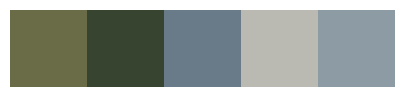

In [12]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
pixels = img.reshape(-1, 3) # flatten to a vector
kmeans = KMeans(n_clusters=5).fit(pixels)
colors = kmeans.cluster_centers_.astype(int)
plt.figure(figsize=(6,1))
plt.imshow([colors])
plt.axis("off")
plt.show()

The colors capture the main colors that appear in the painting. They seem darker that I expected. We can inspect brightness via the brightness distribution histogram below:

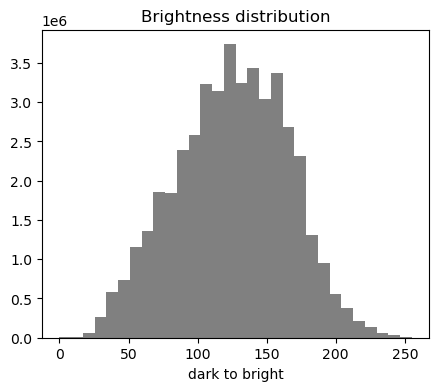

In [14]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(5,4));
plt.hist(gray.ravel(), bins=30, color="gray")
plt.title("Brightness distribution")
plt.xlabel("dark to bright")
plt.show()

As we saw from k-means clustering results, the pixels are only mildly bright. This fits with the overall mild feel the painting creates.